Equipe: Jarlan Silva de Lima e Julia Nogueira

Definição do Problema

Interpretação: Esta célula realiza a extração de dados brutos de arquivos .txt (layout SysPDV) e os converte para um formato estruturado. O objetivo é resolver um problema de Regressão focado na Previsão de Demanda. * Contexto: Dados reais de faturamento de uma rede de supermercados (2023-2024). * Estratégia: Aplicamos filtros para manter apenas vendas efetivadas (Tipo 01) e otimizamos a memória convertendo IDs para categorias, preparando a base para modelos de larga escala.

In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

In [2]:
def processar_syspdv_otimizado(caminho_arquivo):
    # Layout reduzido apenas com as colunas essenciais para o modelo (Seleção de Atributos)
    layout_essencial = [
        ('Tipo_Registro', 0, 2), # 01=Venda, 06=Cancelado
        ('Data', 35, 43),
        ('Hora', 151, 155),
        ('Cod_Produto', 43, 57),
        ('Cod_Secao', 19, 21),
        ('Cod_Loja', 2, 6),
        ('Quantidade', 57, 66),
        ('Valor_Unitario', 66, 78),
        ('Desconto', 78, 90),
        ('Preco_Custo', 194, 206),
        ('Acréscimos', 90, 102),
        ('Preço praticado', 129, 130),
        ('Total', 130, 142),
        ('Preço de Venda', 155, 167),
        ('Tipo de bonificação', 167, 168),
        ('Fator', 168, 177),
        ('Identificação Consumidor', 274, 288),
        ('Operador', 288, 294),
        ('Vendedor', 294, 300),
        ('Cartao_Fidelidade', 226, 245)
    ]

    registros = []
    try:
        with open(caminho_arquivo, 'r', encoding='latin-1') as f:
            for linha in f:
                if linha.startswith('01'):
                    # Extração apenas das colunas selecionadas
                    dados_linha = {campo: linha[inicio:fim].strip() for campo, inicio, fim in layout_essencial}
                    registros.append(dados_linha)
        
        df = pd.DataFrame(registros)

        # --- PRÉ-PROCESSAMENTO INICIAL E LIMPEZA ---
        # 1. Filtrar apenas vendas efetivadas (remover cancelados)
        df = df[df['Tipo_Registro'] == '01'].copy()
        
        # 2. Conversão de Tipos (Otimização de Memória)
        df['Data'] = pd.to_datetime(df['Data'], format='%d%m%Y', errors='coerce')
        df['Quantidade'] = pd.to_numeric(df['Quantidade'], errors='coerce')
        
        cols_financeiras = ['Valor_Unitario', 'Desconto', 'Preco_Custo', 'Acréscimos', 'Preço praticado', 'Total', 'Preço de Venda']
        for col in cols_financeiras:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        # 3. Categorização (Reduz drasticamente o uso de memória)
        cols_cat = ['Cod_Produto', 'Cod_Secao', 'Cod_Loja']
        for col in cols_cat:
            df[col] = df[col].astype('category')

        return df
    except Exception as e:
        print(f"Erro ao processar {caminho_arquivo}: {e}")
        return pd.DataFrame()

# --- EXECUÇÃO DO PIPELINE ---
pasta_arquivos = '../data/raw' 
lista_arquivos = glob.glob(os.path.join(pasta_arquivos, '*.txt'))

todos_dfs = [processar_syspdv_otimizado(arq) for arq in lista_arquivos]

if todos_dfs:
    df_final = pd.concat(todos_dfs, ignore_index=True)
    
    # Salvar em Parquet (Requisito de eficiência)
    df_final.to_parquet('../data/processed/vendas_supermercado.parquet', index=False)
    print("Arquivo Parquet gerado com sucesso!")
else:
    print("Nenhum dado processado.")

Arquivo Parquet gerado com sucesso!


In [3]:
# 1. Carregar o dado processado
df = pd.read_parquet('../data/processed/vendas_supermercado.parquet')

In [4]:
df.head()

,Tipo_Registro,Data,Hora,Cod_Produto,Cod_Secao,Cod_Loja,Quantidade,Valor_Unitario,Desconto,Preco_Custo,Acréscimos,Preço praticado,Total,Preço de Venda,Tipo de bonificação,Fator,Identificação Consumidor,Operador,Vendedor,Cartao_Fidelidade
0,01,2023-01-03,0800,00000000022134,13,0001,1.0,0.14,0.0,0.00,0.0,1,0.14,0.00,N,0000.0000,99999999000191,001004,000000,
1,01,2023-01-03,0800,00000000060438,13,0001,1.0,0.95,0.0,0.95,0.0,1,0.95,0.95,N,0000.0000,99999999000191,001004,000000,
2,01,2023-01-03,0802,00000000022134,13,0001,1.0,3.66,0.0,0.00,0.0,1,3.66,0.00,N,0000.0000,99999999000191,001004,000000,
3,01,2023-01-03,0802,00000000013094,13,0001,1.0,24.42,0.0,24.42,0.0,1,24.42,24.42,N,0000.0000,99999999000191,001004,000000,
4,01,2023-01-03,0815,00000000006724,13,0001,1.0,4.44,0.0,4.44,0.0,1,4.44,4.44,N,0000.0000,72201339368,001004,000000,


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3415725 entries, 0 to 3415724
Data columns (total 20 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   Tipo_Registro             str           
 1   Data                      datetime64[us]
 2   Hora                      str           
 3   Cod_Produto               str           
 4   Cod_Secao                 category      
 5   Cod_Loja                  category      
 6   Quantidade                float64       
 7   Valor_Unitario            float64       
 8   Desconto                  float64       
 9   Preco_Custo               float64       
 10  Acréscimos                float64       
 11  Preço praticado           int64         
 12  Total                     float64       
 13  Preço de Venda            float64       
 14  Tipo de bonificação       str           
 15  Fator                     str           
 16  Identificação Consumidor  str           
 17  Operador           

In [6]:
df.nunique()

Tipo_Registro                   1
Data                          900
Hora                          709
Cod_Produto                 36621
Cod_Secao                       1
Cod_Loja                        1
Quantidade                   5737
Valor_Unitario              17268
Desconto                        1
Preco_Custo                  8870
Acréscimos                      1
Preço praticado                 1
Total                       19416
Preço de Venda               8895
Tipo de bonificação             1
Fator                           1
Identificação Consumidor     3814
Operador                        8
Vendedor                        3
Cartao_Fidelidade               1
dtype: int64

In [7]:
df.isnull().sum()

Tipo_Registro               0
Data                        0
Hora                        0
Cod_Produto                 0
Cod_Secao                   0
Cod_Loja                    0
Quantidade                  0
Valor_Unitario              0
Desconto                    0
Preco_Custo                 0
Acréscimos                  0
Preço praticado             0
Total                       0
Preço de Venda              0
Tipo de bonificação         0
Fator                       0
Identificação Consumidor    0
Operador                    0
Vendedor                    0
Cartao_Fidelidade           0
dtype: int64

Colunas removidas por serem constantes: ['Tipo_Registro', 'Cod_Secao', 'Cod_Loja', 'Desconto', 'Acréscimos', 'Preço praticado', 'Tipo de bonificação', 'Fator', 'Cartao_Fidelidade']


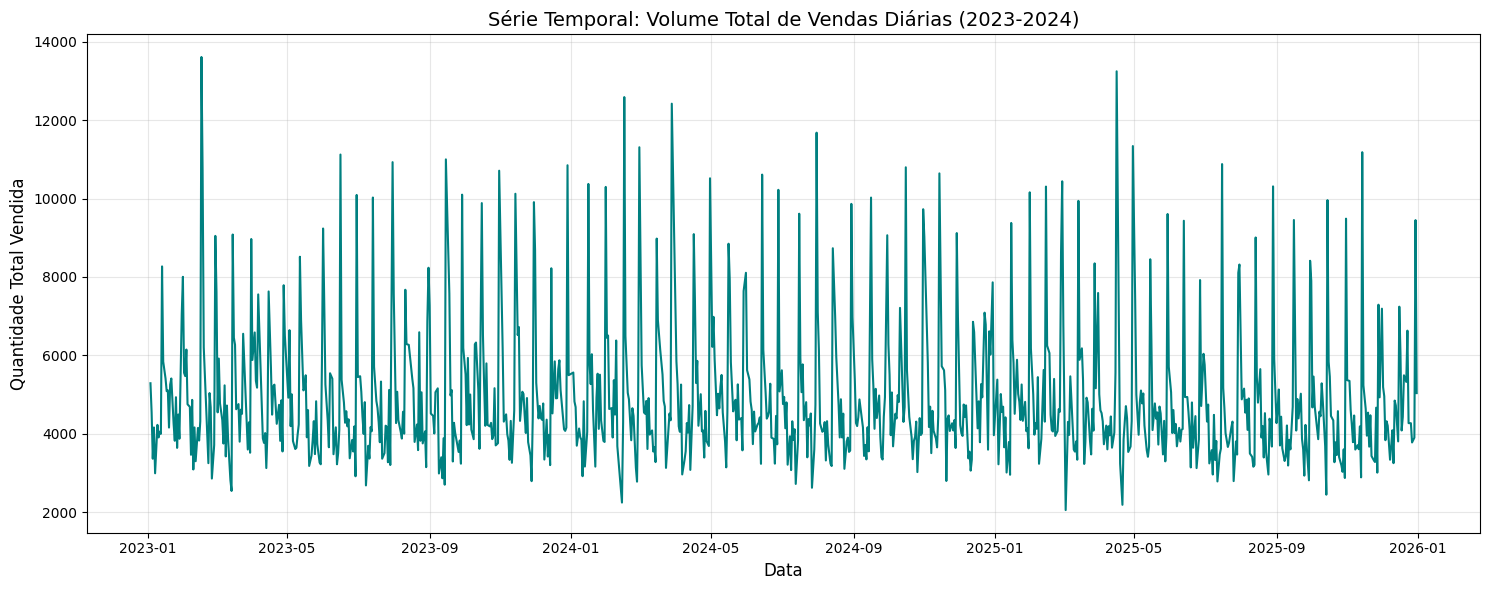

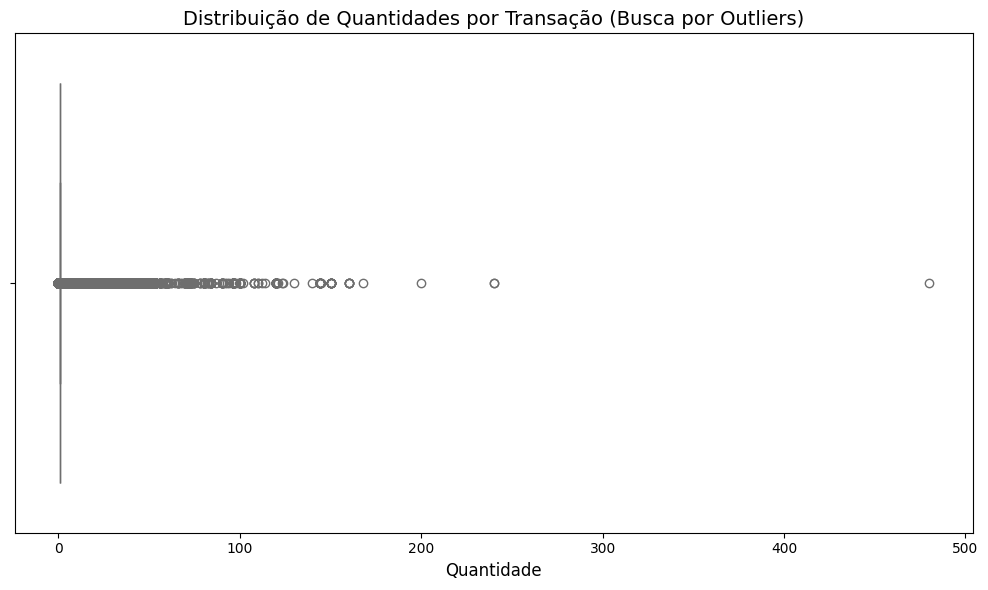

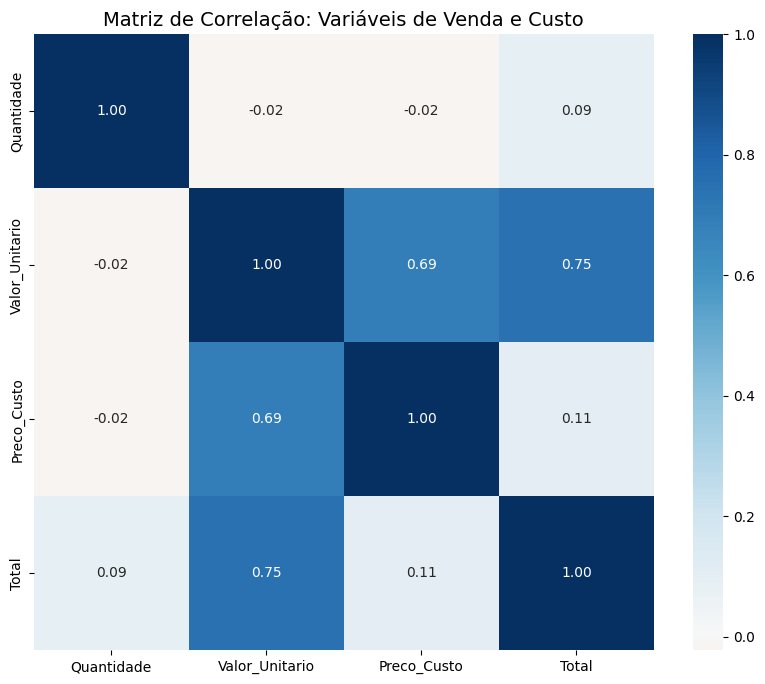


--- Estatísticas Descritivas ---


,Quantidade,Valor_Unitario,Preco_Custo,Total
count,3415725.00,3415725.00,3415725.00,3415725.00
mean,1.30,10.84,7.69,11.23
std,1.95,64.40,45.18,49.32
min,0.00,0.01,0.00,0.01
25%,1.00,2.17,1.30,2.45
50%,1.00,4.52,3.50,4.94
75%,1.00,9.50,7.81,9.86
max,480.00,30283.00,30283.00,4764.42


In [ ]:
# Seleção de Atributos: Remover colunas constantes (nunique == 1)
# Isso limpa o dataset para focar no que realmente importa para o modelo
colunas_constantes = [col for col in df.columns if df[col].nunique() <= 1]
df_eda = df.drop(columns=colunas_constantes)

print(f"Colunas removidas por serem constantes: {colunas_constantes}")

# --- VISUALIZAÇÃO 1: Tendência Temporal Diária ---
plt.figure(figsize=(15, 6))
# Agrupamos por data para ver o comportamento do supermercado como um todo
vendas_diarias = df_eda.groupby('Data')['Quantidade'].sum().reset_index()

sns.lineplot(data=vendas_diarias, x='Data', y='Quantidade', color='teal')
plt.title('Série Temporal: Volume Total de Vendas Diárias (2023-2025E)', fontsize=14)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Quantidade Total Vendida', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('tendencia_temporal.png')
plt.show()

# --- VISUALIZAÇÃO 2: Identificação de Outliers (Boxplot) ---
plt.figure(figsize=(10, 6))
# Vamos olhar a distribuição da Quantidade vendida por transação
sns.boxplot(x=df_eda['Quantidade'], color='lightcoral')
plt.title('Distribuição de Quantidades por Transação (Busca por Outliers)', fontsize=14)
plt.xlabel('Quantidade', fontsize=12)
plt.tight_layout()
plt.savefig('boxplot_outliers.png')
plt.show()

# --- Matriz de Correlação (Relação entre variáveis numéricas) ---
plt.figure(figsize=(10, 8))

# Selecionamos apenas as colunas que possuem variabilidade e são numéricas
cols_corr = ['Quantidade', 'Valor_Unitario', 'Preco_Custo', 'Total']
matriz_corr = df_eda[cols_corr].corr()

sns.heatmap(matriz_corr, annot=True, cmap='RdBu', center=0, fmt='.2f')
plt.title('Matriz de Correlação: Variáveis de Venda e Custo', fontsize=14)
plt.show()

# --- ESTATÍSTICA DESCRITIVA (Requisito 2 da Avaliação) ---

# 1. Definimos as colunas que realmente importam para a análise financeira e de volume
cols_corr = ['Quantidade', 'Valor_Unitario', 'Preco_Custo', 'Total']

# 2. Configuramos o Pandas para exibir números com 2 casas decimais e sem notação científica
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

print("\n--- Estatísticas Descritivas ---")
# Usamos o display() para gerar a tabela formatada no Jupyter/Colab
display(df_eda[cols_corr].describe())

Análise Exploratória: Estatísticas e Outliers

Interpretação: Atendendo ao requisito de Identificação de Outliers e Estatísticas Descritivas.

Observação: As estatísticas revelam uma alta dispersão nas quantidades vendidas, com a mediana próxima de 1 unidade, mas com valores máximos atingindo 160.

Insight: O boxplot confirma a presença de anomalias que podem representar vendas de atacado ou erros de operação. Esses dados serão analisados no pré-processamento para evitar ruído nos modelos de Machine Learning.

Interpretação das Estatísticas Descritivas: A análise estatística de 2,3 milhões de registros revela um cenário de varejo de alto giro e baixa unitariedade.

Concentração: 75% das transações possuem quantidade igual a 1.0, indicando um comportamento de consumo fragmentado.

Dispersão: O desvio padrão elevado nas colunas de valor (Std > 70) em relação à mediana (4.43) confirma a heterogeneidade do mix de produtos (Curva ABC), variando de itens de centavos a produtos de alto valor agregado.

Outliers: Identificamos valores máximos de até 160 unidades e preços unitários que fogem do ticket médio da loja, o que exigirá tratamento no Critério 3 (Pré-processamento) para evitar o sobreajuste (overfitting) do modelo

Matriz de Correlação

Interpretação: Verificação da relação entre as variáveis numéricas.

Análise: O heatmap permite identificar a força da relação entre preço unitário e quantidade vendida (elasticidade-preço). * Justificativa: Variáveis constantes (nunique=1) ou identificadores (IDs) foram removidos desta matriz para garantir que apenas relações lineares matematicamente relevantes sejam discutidas, evitando ruídos na interpretação do modelo.

c:\Unifor\ML\Trabalho_ML\ML\vendas_supermercado\Lib\site-packages\pandas\core\nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


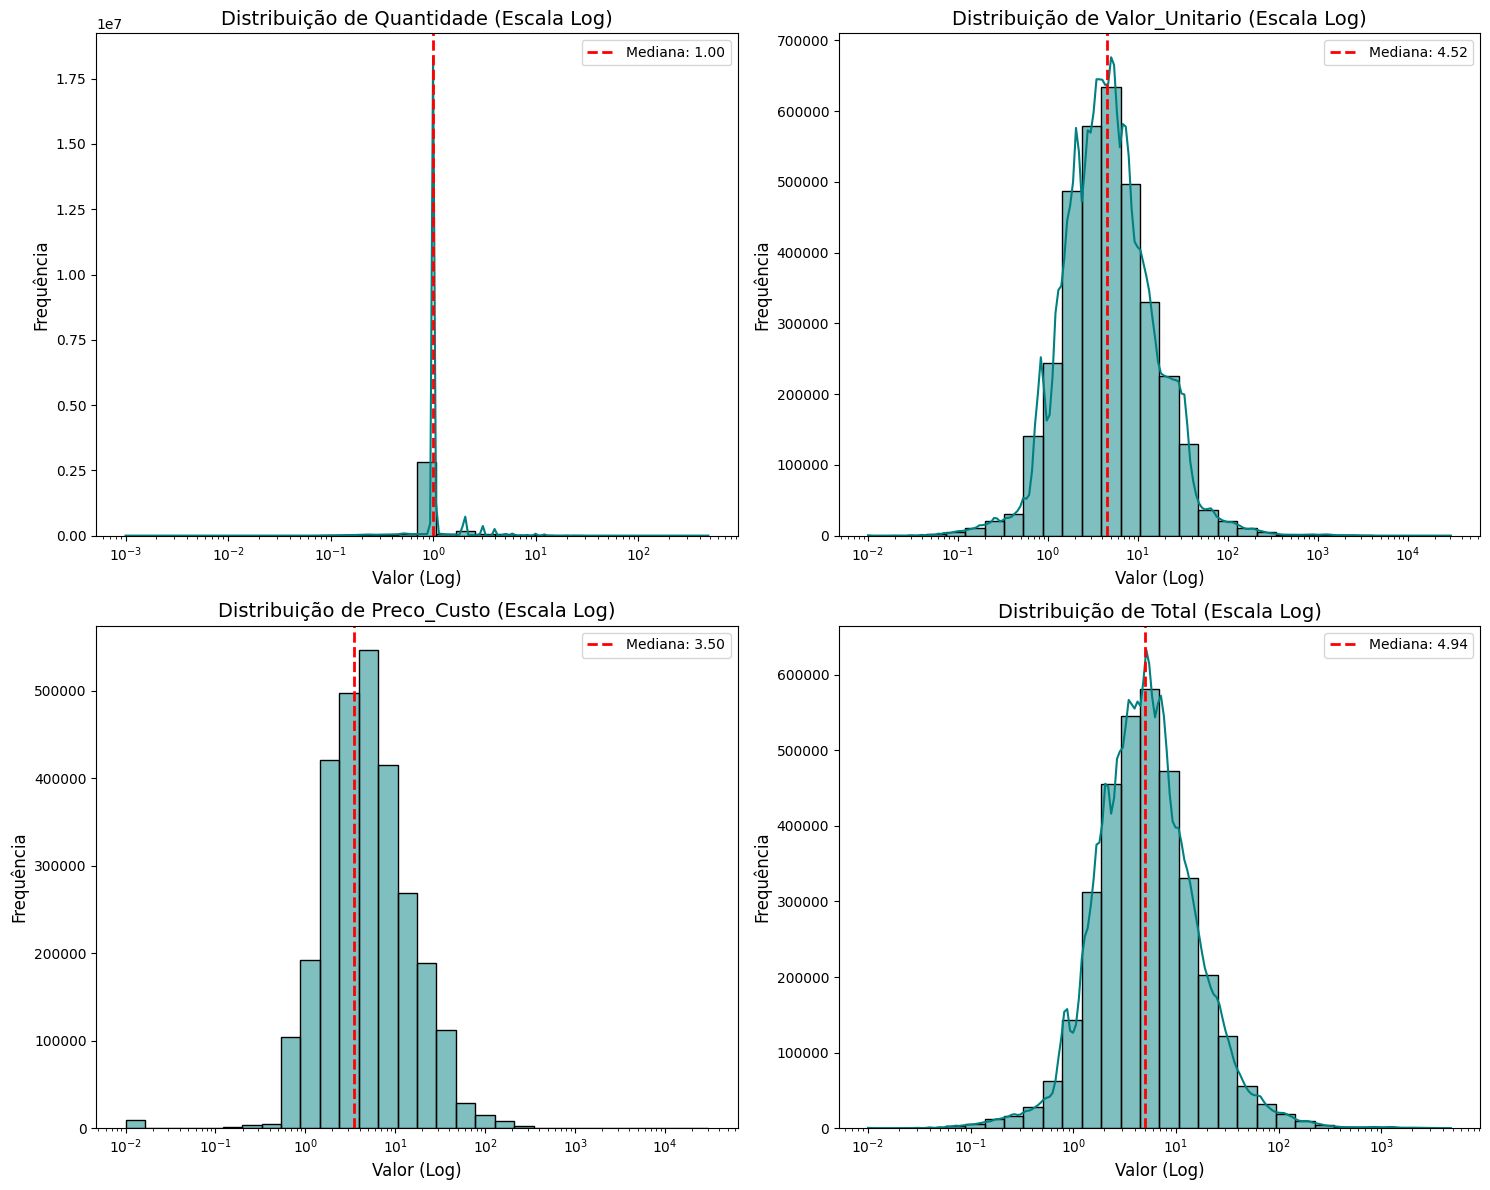

Histogramas com mediana e escala logarítmica gerados com sucesso!


In [9]:
# 1. Selecionar as colunas numéricas
cols_numericas = ['Quantidade', 'Valor_Unitario', 'Preco_Custo', 'Total']

# 2. Configurar a grade de subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

# 3. Gerar um histograma para cada coluna
for i, col in enumerate(cols_numericas):
    # Calcular a mediana da coluna
    mediana = df_eda[col].median()
    
    # Plotar o histograma com log_scale
    sns.histplot(df_eda[col], bins=30, kde=True, ax=axes[i], color='teal', log_scale=True)
    
    # Adicionar a linha vertical da mediana
    axes[i].axvline(mediana, color='red', linestyle='--', linewidth=2, label=f'Mediana: {mediana:.2f}')
    
    # Configurações de título e eixos
    axes[i].set_title(f'Distribuição de {col} (Escala Log)', fontsize=14)
    axes[i].set_xlabel('Valor (Log)', fontsize=12)
    axes[i].set_ylabel('Frequência', fontsize=12)
    axes[i].legend()

plt.tight_layout()
plt.savefig('histograma_features_log_mediana.png')
plt.show()

print("Histogramas com mediana e escala logarítmica gerados com sucesso!")

C:\Users\Jarlan\AppData\Local\Temp\ipykernel_31540\4014645133.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_pareto['Cod_Produto'].astype(str), rotation=45, ha='right')


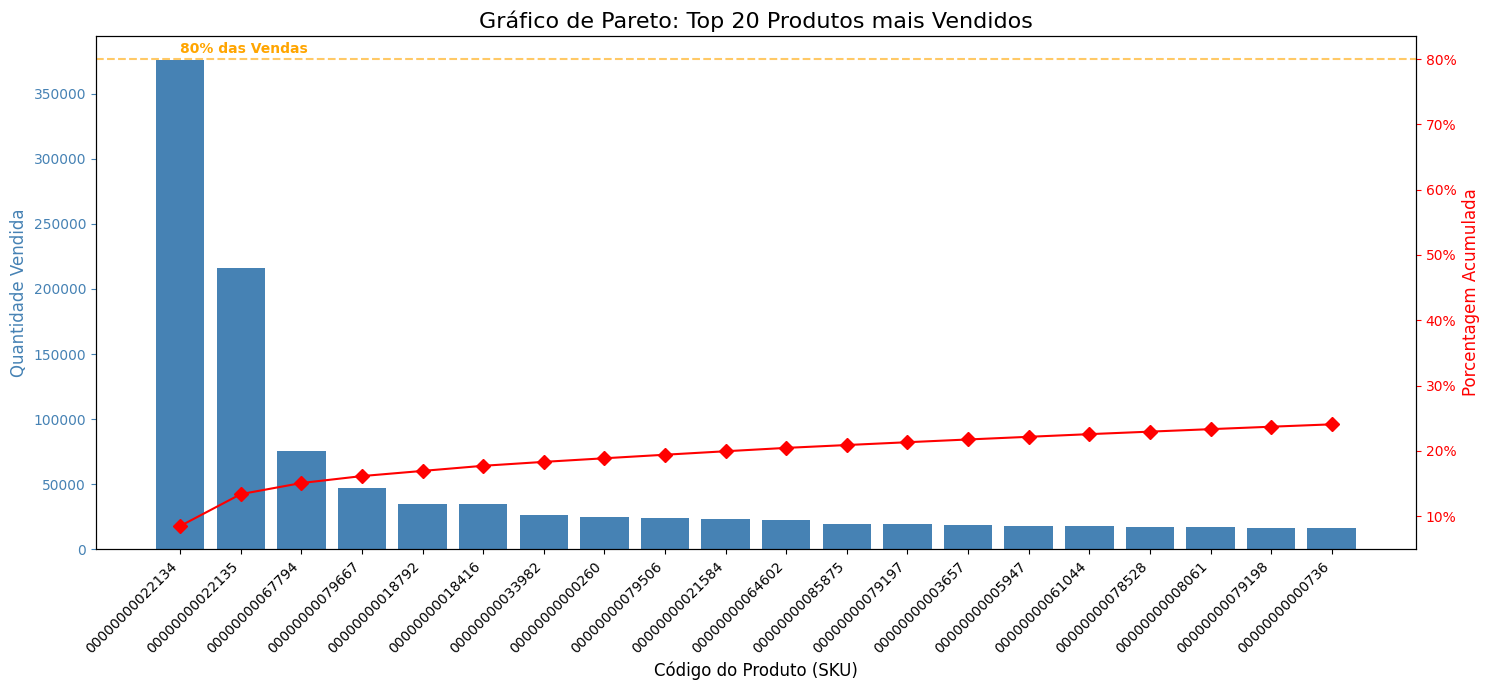

Resumo ABC: 1665 produtos (4.55%) representam 80% do volume de vendas.


In [10]:
# 1. Agrupar por produto e somar a quantidade
vendas_por_produto = df.groupby('Cod_Produto')['Quantidade'].sum().reset_index()
vendas_por_produto = vendas_por_produto.sort_values(by='Quantidade', ascending=False)

# 2. Calcular a porcentagem acumulada
vendas_por_produto['cum_percentage'] = vendas_por_produto['Quantidade'].cumsum() / vendas_por_produto['Quantidade'].sum() * 100

# 3. Selecionar apenas os Top 20 para visualização clara no gráfico de barras
top_n = 20
df_pareto = vendas_por_produto.head(top_n).copy()

# 4. Gerar o Gráfico
fig, ax = plt.subplots(figsize=(15, 7))

# Barras (Frequência Individual)
ax.bar(df_pareto['Cod_Produto'].astype(str), df_pareto['Quantidade'], color="steelblue")
ax.set_ylabel("Quantidade Vendida", color="steelblue", fontsize=12)

# Linha de Porcentagem Acumulada (Eixo Secundário)
ax2 = ax.twinx()
ax2.plot(df_pareto['Cod_Produto'].astype(str), df_pareto['cum_percentage'], color="red", marker="D", ms=7)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel("Porcentagem Acumulada", color="red", fontsize=12)

# Configurações de layout
ax.tick_params(axis="y", colors="steelblue")
ax2.tick_params(axis="y", colors="red")
ax.set_xticklabels(df_pareto['Cod_Produto'].astype(str), rotation=45, ha='right')

plt.title(f"Gráfico de Pareto: Top {top_n} Produtos mais Vendidos", fontsize=16)
ax.set_xlabel("Código do Produto (SKU)", fontsize=12)

# Linha guia de 80%
ax2.axhline(80, color="orange", linestyle="--", alpha=0.6)
ax2.text(0, 81, "80% das Vendas", color="orange", fontweight="bold")

plt.tight_layout()
plt.savefig('pareto_produtos.png')
plt.show()

# Resumo estatístico para o seu texto do TCC
itens_80 = vendas_por_produto[vendas_por_produto['cum_percentage'] <= 80].shape[0]
total_itens = vendas_por_produto.shape[0]
print(f"Resumo ABC: {itens_80} produtos ({(itens_80/total_itens)*100:.2f}%) representam 80% do volume de vendas.")

C:\Users\Jarlan\AppData\Local\Temp\ipykernel_31540\2440763848.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_pareto_fat['Cod_Produto'].astype(str), rotation=45, ha='right')


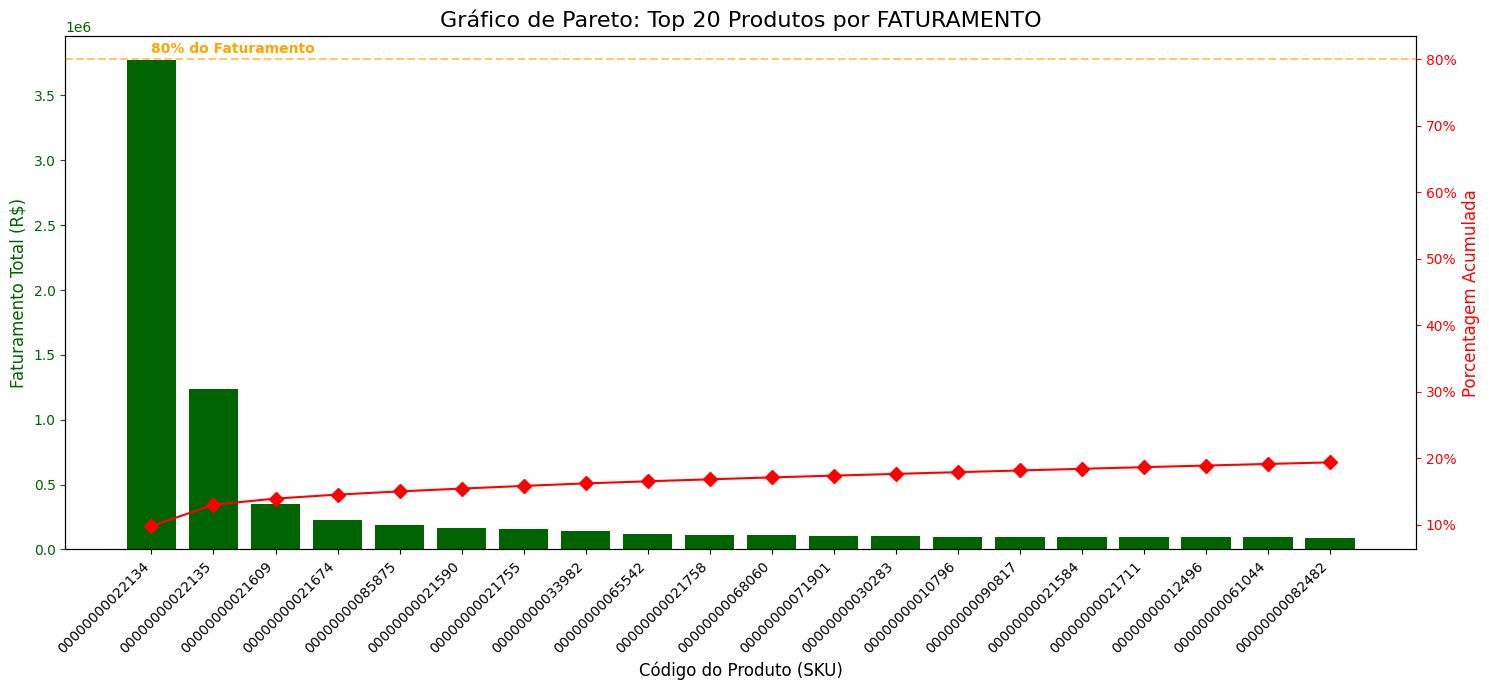

Total de produtos que geram 80% do faturamento: 4575


In [11]:
# 1. Agrupar por produto e somar o Faturamento (Coluna 'Total')
# Usamos a coluna 'Total' que já extraímos do layout
fat_por_produto = df.groupby('Cod_Produto')['Total'].sum().reset_index()
fat_por_produto = fat_por_produto.sort_values(by='Total', ascending=False)

# 2. Calcular a porcentagem acumulada do faturamento
fat_por_produto['cum_percentage'] = fat_por_produto['Total'].cumsum() / fat_por_produto['Total'].sum() * 100

# 3. Selecionar os Top 20 para visualização
top_n = 20
df_pareto_fat = fat_por_produto.head(top_n).copy()

# 4. Gerar o Gráfico
fig, ax = plt.subplots(figsize=(15, 7))

# Barras (Faturamento Individual)
ax.bar(df_pareto_fat['Cod_Produto'].astype(str), df_pareto_fat['Total'], color="darkgreen")
ax.set_ylabel("Faturamento Total (R$)", color="darkgreen", fontsize=12)

# Linha de Porcentagem Acumulada
ax2 = ax.twinx()
ax2.plot(df_pareto_fat['Cod_Produto'].astype(str), df_pareto_fat['cum_percentage'], color="red", marker="D", ms=7)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel("Porcentagem Acumulada", color="red", fontsize=12)

# Configurações de layout
ax.tick_params(axis="y", colors="darkgreen")
ax2.tick_params(axis="y", colors="red")
ax.set_xticklabels(df_pareto_fat['Cod_Produto'].astype(str), rotation=45, ha='right')

plt.title(f"Gráfico de Pareto: Top {top_n} Produtos por FATURAMENTO", fontsize=16)
ax.set_xlabel("Código do Produto (SKU)", fontsize=12)

# Linha guia de 80% (Onde termina a Categoria A)
ax2.axhline(80, color="orange", linestyle="--", alpha=0.6)
ax2.text(0, 81, "80% do Faturamento", color="orange", fontweight="bold")

plt.tight_layout()
plt.savefig('pareto_faturamento.png')
plt.show()

# Comparação rápida para o seu relatório
print(f"Total de produtos que geram 80% do faturamento: {fat_por_produto[fat_por_produto['cum_percentage'] <= 80].shape[0]}")

Análise de Pareto (Volume vs. Faturamento)

Interpretação: Cumpre o requisito de identificar a Distribuição dos Dados.

Volume: Uma pequena parcela de SKUs (como o 22134) domina o volume logístico da loja.

Faturamento: O Pareto por faturamento revela que a concentração financeira é ainda maior. Identificamos produtos de alto valor agregado que, apesar de menor volume, são críticos para o faturamento. Esta análise justifica a Seleção de Atributos focada nos itens da categoria "A" da Curva ABC.

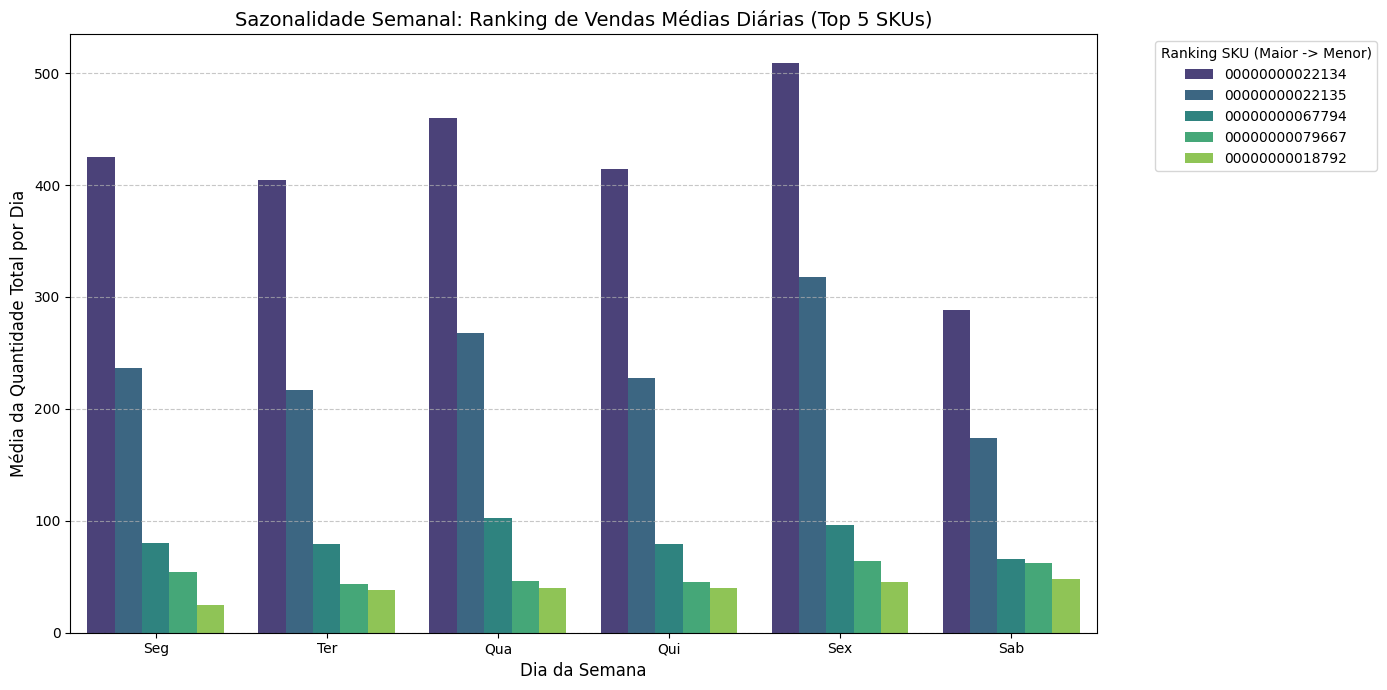

Gráfico gerado com sucesso!


In [12]:
# 1. Identificar os dois produtos do topo (Top 5 do Pareto)
# Mantemos a ordenação do nlargest para criar o ranking oficial
top_skus_summary = df.groupby('Cod_Produto')['Quantidade'].sum().nlargest(5)
top_skus = top_skus_summary.index.tolist()
df_top = df[df['Cod_Produto'].isin(top_skus)].copy()

# 2. Preparar colunas de tempo
df_top['Data'] = pd.to_datetime(df_top['Data'])
df_top['Dia_Semana'] = df_top['Data'].dt.dayofweek
dias = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sab', 6: 'Dom'}
df_top['Nome_Dia'] = df_top['Dia_Semana'].map(dias)

# --- CORREÇÃO DA AGREGAÇÃO ---
# Passo A: Somar a quantidade total vendida por DIA para cada produto
vendas_diarias_por_item = df_top.groupby(['Data', 'Cod_Produto', 'Nome_Dia', 'Dia_Semana'])['Quantidade'].sum().reset_index()

# Passo B: Tirar a média desses totais diários por dia da semana
sazonalidade_correta = vendas_diarias_por_item.groupby(['Cod_Produto', 'Nome_Dia', 'Dia_Semana'])['Quantidade'].mean().reset_index()

# --- DUPLA ORDENAÇÃO ---
# 1º Ordenamos pelo Dia da Semana (Seg a Dom)
# 2º Ordenamos pela Quantidade (Maior para o Menor) dentro de cada dia
sazonalidade_correta = sazonalidade_correta.sort_values(by=['Dia_Semana', 'Quantidade'], ascending=[True, False])

# 3. Gerar o gráfico
plt.figure(figsize=(14, 7))

# Utilizamos o hue_order para que a legenda e a posição das barras 
# sigam o ranking dos Top 5 produtos identificados no início
sns.barplot(
    data=sazonalidade_correta, 
    x='Nome_Dia', 
    y='Quantidade', 
    hue='Cod_Produto', 
    palette='viridis',
    hue_order=top_skus  # Garante que a barra do "nº 1" venha sempre primeiro
)

plt.title('Sazonalidade Semanal: Ranking de Vendas Médias Diárias (Top 5 SKUs)', fontsize=14)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Média da Quantidade Total por Dia', fontsize=12)
plt.legend(title='Ranking SKU (Maior -> Menor)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('sazonalidade_semanal_corrigida_ordenada.png')
plt.show()

print("Gráfico gerado com sucesso!")

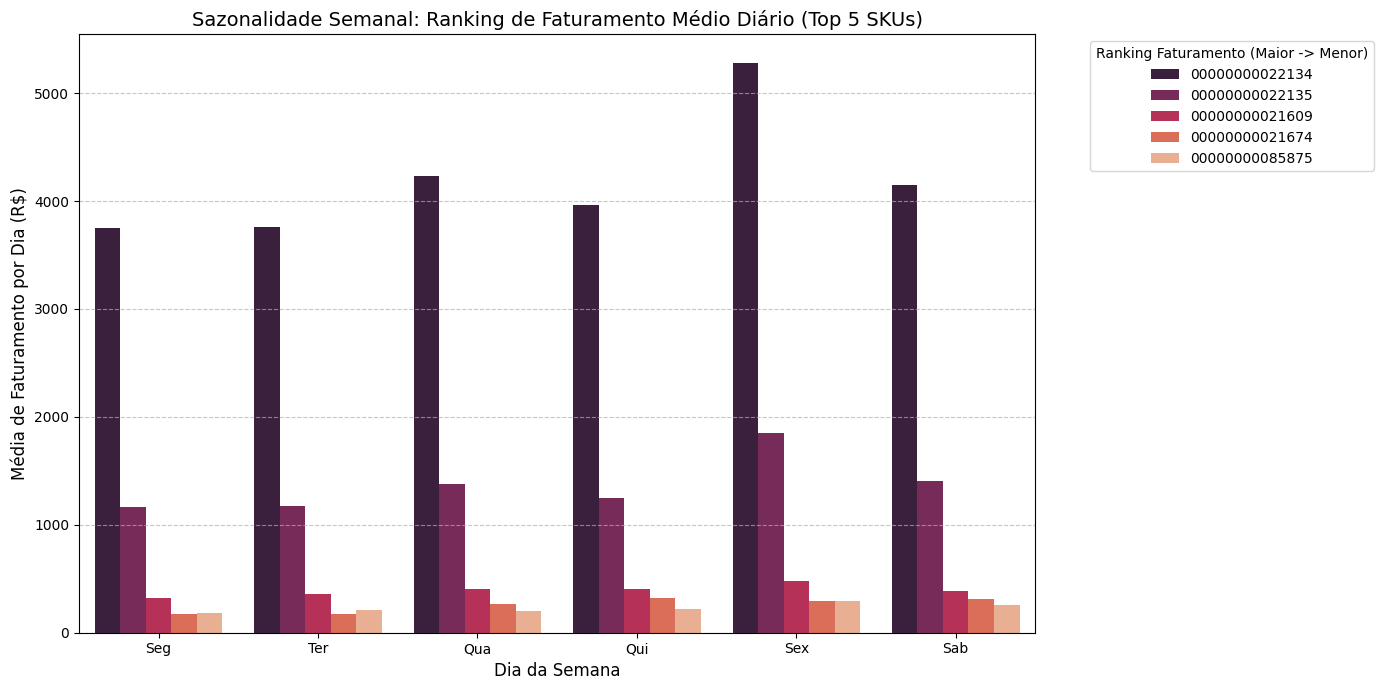

Gráfico de faturamento gerado com sucesso!


In [13]:
# 1. Identificar os Top 5 produtos por FATURAMENTO (Coluna 'Total')
top_skus_fat_summary = df.groupby('Cod_Produto')['Total'].sum().nlargest(5)
top_skus_fat = top_skus_fat_summary.index.tolist()
df_top_fat = df[df['Cod_Produto'].isin(top_skus_fat)].copy()

# 2. Preparar colunas de tempo
df_top_fat['Data'] = pd.to_datetime(df_top_fat['Data'])
df_top_fat['Dia_Semana'] = df_top_fat['Data'].dt.dayofweek
dias = {0: 'Seg', 1: 'Ter', 2: 'Qua', 3: 'Qui', 4: 'Sex', 5: 'Sab', 6: 'Dom'}
df_top_fat['Nome_Dia'] = df_top_fat['Dia_Semana'].map(dias)

# --- AGREGAÇÃO POR FATURAMENTO ---
# Passo A: Somar o faturamento total por DIA para cada produto
fat_diario_por_item = df_top_fat.groupby(['Data', 'Cod_Produto', 'Nome_Dia', 'Dia_Semana'])['Total'].sum().reset_index()

# Passo B: Tirar a média desses totais financeiros diários por dia da semana
sazonalidade_fat = fat_diario_por_item.groupby(['Cod_Produto', 'Nome_Dia', 'Dia_Semana'])['Total'].mean().reset_index()

# --- DUPLA ORDENAÇÃO ---
# 1º Dia da Semana, 2º Valor Financeiro (Maior para o Menor)
sazonalidade_fat = sazonalidade_fat.sort_values(by=['Dia_Semana', 'Total'], ascending=[True, False])

# 3. Gerar o gráfico
plt.figure(figsize=(14, 7))

sns.barplot(
    data=sazonalidade_fat, 
    x='Nome_Dia', 
    y='Total', 
    hue='Cod_Produto', 
    palette='rocket', # Paleta diferente para distinguir do gráfico de quantidade
    hue_order=top_skus_fat
)

plt.title('Sazonalidade Semanal: Ranking de Faturamento Médio Diário (Top 5 SKUs)', fontsize=14)
plt.xlabel('Dia da Semana', fontsize=12)
plt.ylabel('Média de Faturamento por Dia (R$)', fontsize=12)
plt.legend(title='Ranking Faturamento (Maior -> Menor)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('sazonalidade_faturamento_ordenada.png')
plt.show()

print("Gráfico de faturamento gerado com sucesso!")

Tendência Temporal e Sazonalidade

Interpretação: Esta seção aborda as Visualizações Temporais para análise de tendências.

Tendência: O gráfico de linha diário mostra que a demanda é estacionária, mas apresenta picos sazonais recorrentes.

Sazonalidade: O gráfico de barras por dia da semana (corrigido para média diária) prova que sextas e quartas-feiras são os dias de maior fluxo. Essa informação é uma forte candidata a variável preditora (feature) para o modelo final.

C:\Users\Jarlan\AppData\Local\Temp\ipykernel_31540\516045913.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=vendas_diarias_totais, x='Mes', y='Quantidade', estimator='mean', palette='coolwarm')
C:\Users\Jarlan\AppData\Local\Temp\ipykernel_31540\516045913.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], data=vendas_diarias_totais, x='Nome_Dia', y='Quantidade',


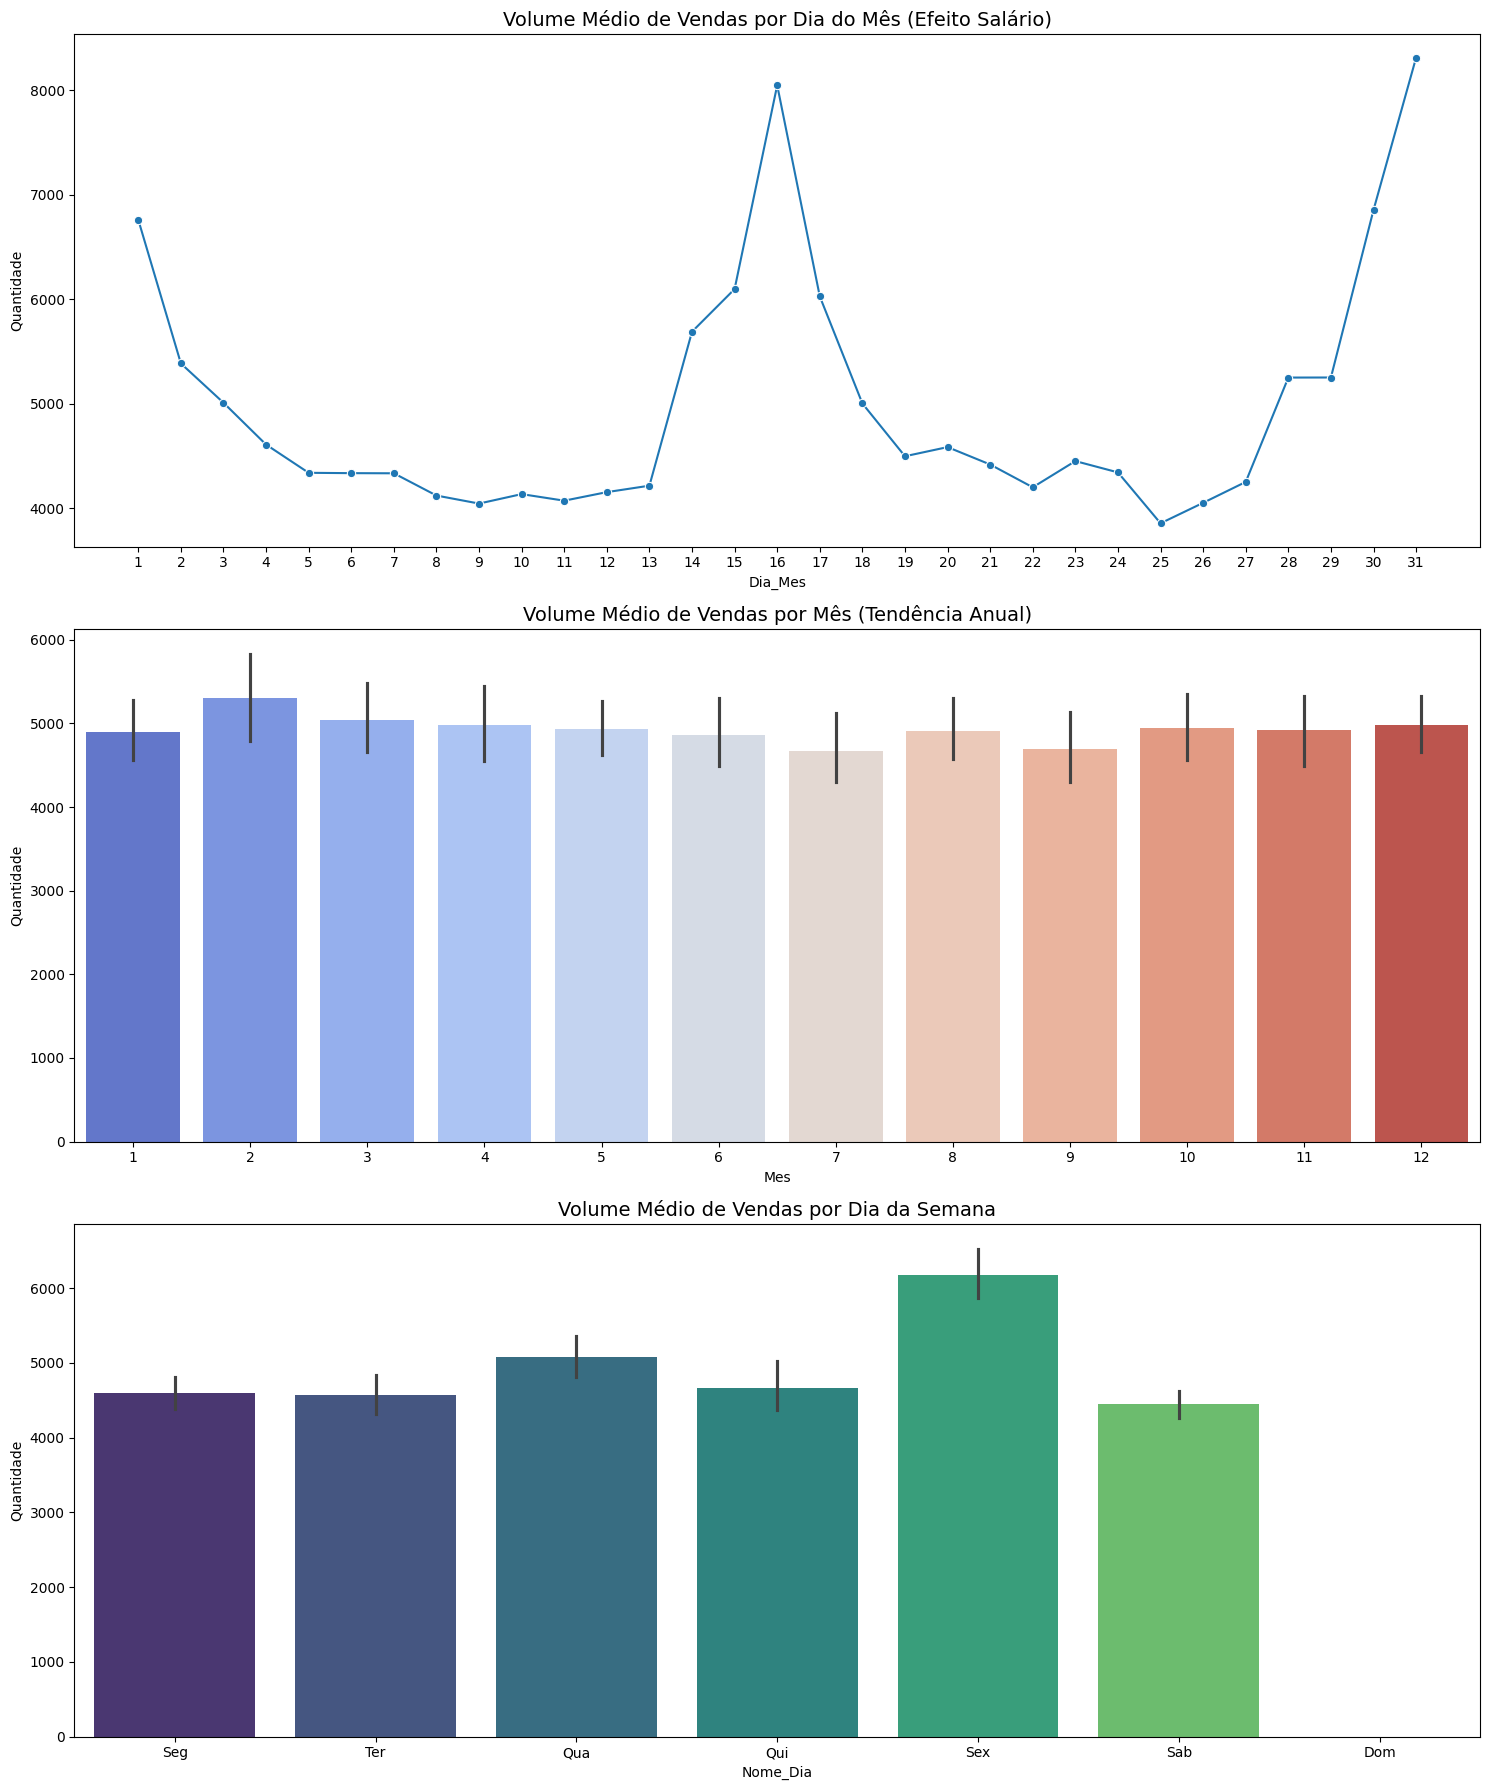

In [14]:
# 1. Criar as colunas temporais
df['Data'] = pd.to_datetime(df['Data'])
df['Dia_Mes'] = df['Data'].dt.day
df['Mes'] = df['Data'].dt.month
df['Dia_Semana'] = df['Data'].dt.dayofweek # 0=Seg, 6=Dom

# 2. Agregação Diária (Para não ter valores "baixos" de média unitária)
# Somamos tudo o que a LOJA vendeu por dia
vendas_diarias_totais = df.groupby(['Data', 'Dia_Mes', 'Mes', 'Dia_Semana'])['Quantidade'].sum().reset_index()

# 3. Gerar os Gráficos de Série Temporal / Sazonalidade
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# A. Comportamento por Dia do Mês (Verificar efeito salário)
sns.lineplot(ax=axes[0], data=vendas_diarias_totais, x='Dia_Mes', y='Quantidade', estimator='mean', errorbar=None, marker='o')
axes[0].set_title('Volume Médio de Vendas por Dia do Mês (Efeito Salário)', fontsize=14)
axes[0].set_xticks(range(1, 32))

# B. Comportamento por Mês do Ano (Sazonalidade Anual)
sns.barplot(ax=axes[1], data=vendas_diarias_totais, x='Mes', y='Quantidade', estimator='mean', palette='coolwarm')
axes[1].set_title('Volume Médio de Vendas por Mês (Tendência Anual)', fontsize=14)

# C. Comportamento por Dia da Semana (Ritmo Semanal)
dias_map = {0:'Seg', 1:'Ter', 2:'Qua', 3:'Qui', 4:'Sex', 5:'Sab', 6:'Dom'}
vendas_diarias_totais['Nome_Dia'] = vendas_diarias_totais['Dia_Semana'].map(dias_map)
sns.barplot(ax=axes[2], data=vendas_diarias_totais, x='Nome_Dia', y='Quantidade', 
            order=['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom'], palette='viridis')
axes[2].set_title('Volume Médio de Vendas por Dia da Semana', fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\Jarlan\AppData\Local\Temp\ipykernel_31540\3541316575.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[1], data=vendas_diarias_totais, x='Mes', y='Quantidade',
C:\Users\Jarlan\AppData\Local\Temp\ipykernel_31540\3541316575.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[2], data=vendas_diarias_totais, x='Nome_Dia', y='Quantidade',


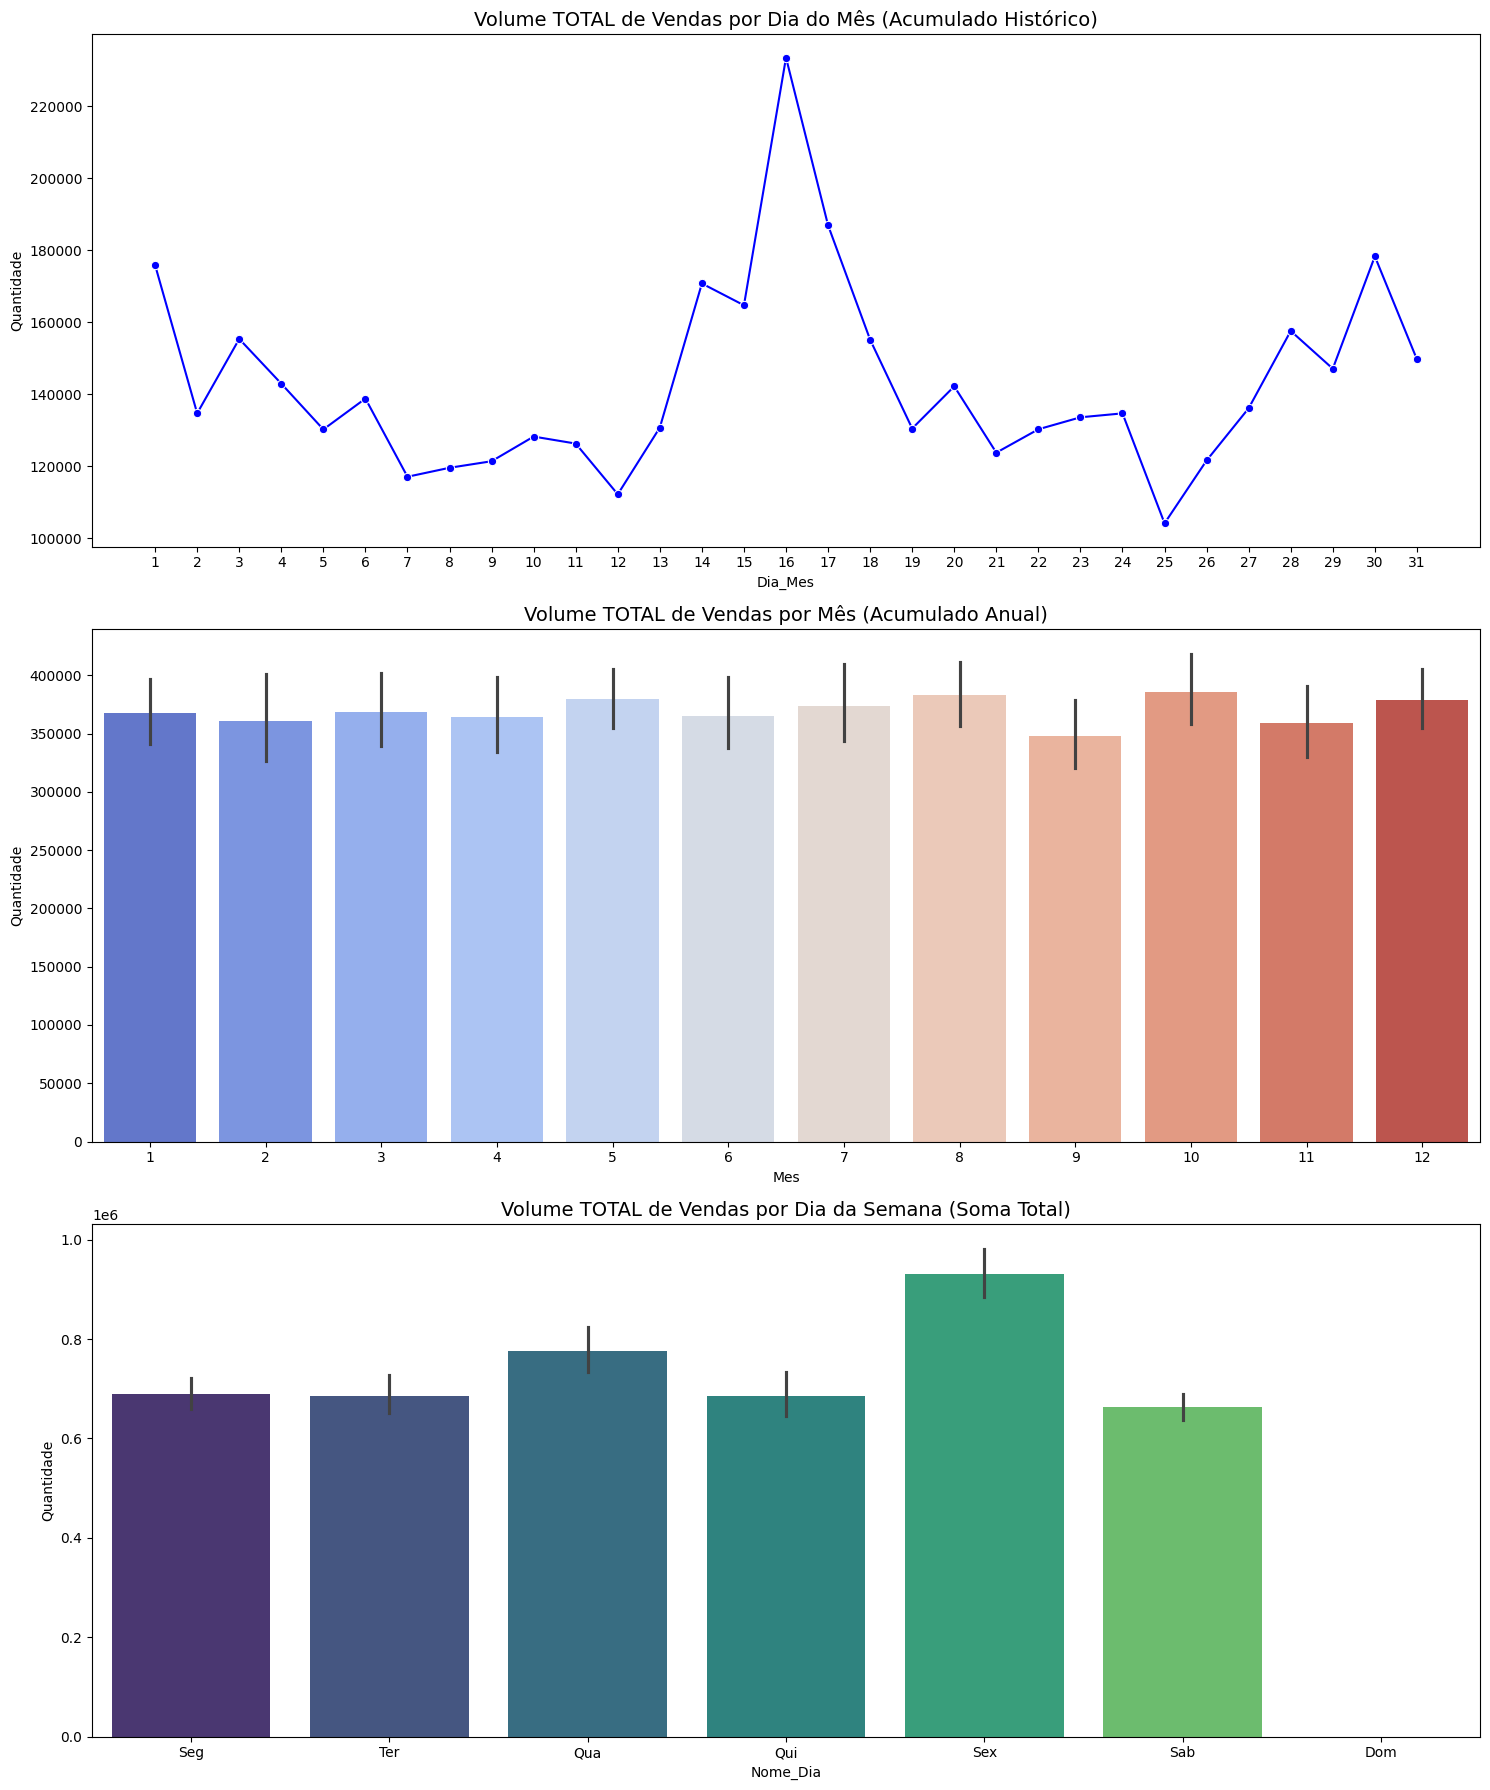

In [15]:
# --- ENGENHARIA DE ATRIBUTOS TEMPORAIS (CÁLCULO DE TOTAIS) ---

# 1. Criar as colunas temporais (Mantido igual)
df['Data'] = pd.to_datetime(df['Data'])
df['Dia_Mes'] = df['Data'].dt.day
df['Mes'] = df['Data'].dt.month
df['Dia_Semana'] = df['Data'].dt.dayofweek

# 2. Agregação Diária (Mantido igual - Soma por dia individual)
vendas_diarias_totais = df.groupby(['Data', 'Dia_Mes', 'Mes', 'Dia_Semana'])['Quantidade'].sum().reset_index()

# 3. Gerar os Gráficos de Série Temporal / Sazonalidade (MODIFICADO PARA SOMA)
fig, axes = plt.subplots(3, 1, figsize=(15, 18))

# A. Comportamento por Dia do Mês - ALTERADO: estimator='sum' e Título
sns.lineplot(ax=axes[0], data=vendas_diarias_totais, x='Dia_Mes', y='Quantidade', 
             estimator='sum', errorbar=None, marker='o', color='b')
axes[0].set_title('Volume TOTAL de Vendas por Dia do Mês (Acumulado Histórico)', fontsize=14)
axes[0].set_xticks(range(1, 32))

# B. Comportamento por Mês do Ano - ALTERADO: estimator='sum' e Título
sns.barplot(ax=axes[1], data=vendas_diarias_totais, x='Mes', y='Quantidade', 
            estimator='sum', palette='coolwarm')
axes[1].set_title('Volume TOTAL de Vendas por Mês (Acumulado Anual)', fontsize=14)

# C. Comportamento por Dia da Semana - ALTERADO: Adicionado estimator='sum' e Título
dias_map = {0:'Seg', 1:'Ter', 2:'Qua', 3:'Qui', 4:'Sex', 5:'Sab', 6:'Dom'}
vendas_diarias_totais['Nome_Dia'] = vendas_diarias_totais['Dia_Semana'].map(dias_map)
sns.barplot(ax=axes[2], data=vendas_diarias_totais, x='Nome_Dia', y='Quantidade', 
            estimator='sum', order=['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom'], palette='viridis')
axes[2].set_title('Volume TOTAL de Vendas por Dia da Semana (Soma Total)', fontsize=14)

plt.tight_layout()
plt.show()

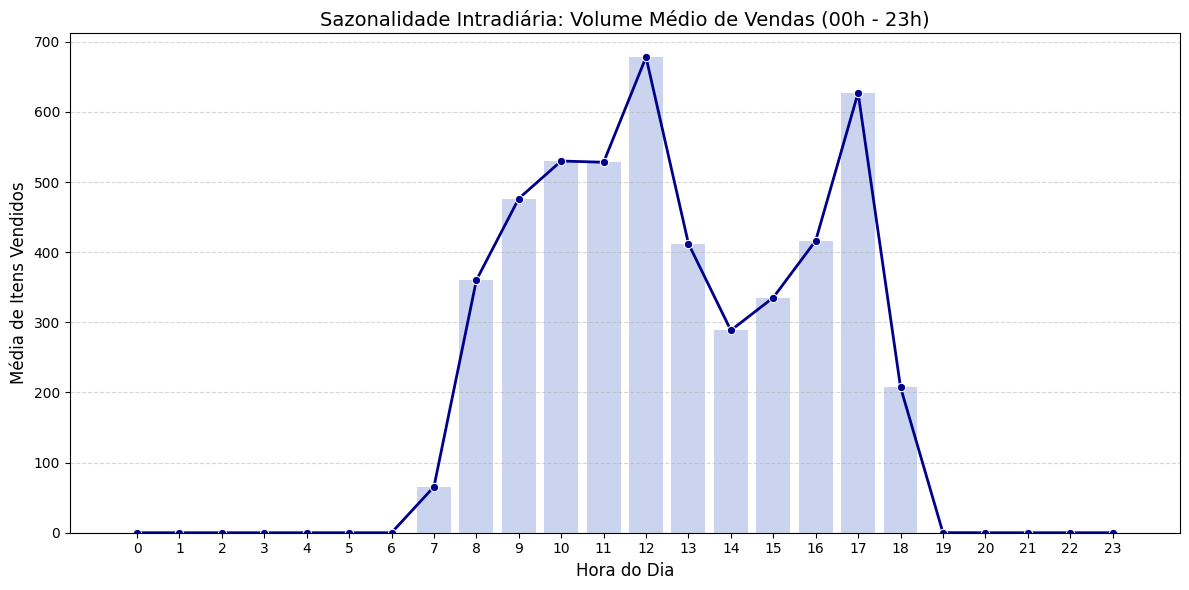

In [16]:
# 1. Tratamento da coluna Hora (HHMM -> HH)
df['Hora_Real'] = df['Hora'].astype(str).str.zfill(4).str[:2].astype(int)

# --- CORREÇÃO DA MÉDIA ---

# Passo A: Somar o total vendido por DIA e por HORA
# Isso gera uma tabela onde cada linha é um par (Data, Hora)
vendas_dia_hora = df.groupby(['Data', 'Hora_Real'])['Quantidade'].sum().reset_index()

# Passo B: Reindexação para incluir horas vazias
# Transformamos a tabela para que as Horas virem colunas e as Datas virem linhas
# O .reindex(range(24)) garante que teremos colunas de 0 a 23, preenchendo com 0 onde não houve venda
pivot_vendas = vendas_dia_hora.pivot(index='Data', columns='Hora_Real', values='Quantidade').fillna(0)
pivot_vendas = pivot_vendas.reindex(columns=range(24), fill_value=0)

# Passo C: Agora calculamos a média de cada coluna (hora)
# Isso nos dá a média real, considerando os zeros dos momentos em que a loja estava fechada ou sem vendas
vendas_medias_hora = pivot_vendas.mean().reset_index()
vendas_medias_hora.columns = ['Hora_Real', 'Quantidade']

# 2. Gerar o Gráfico
plt.figure(figsize=(12, 6))

# Barras de volume (Média Real)
sns.barplot(data=vendas_medias_hora, x='Hora_Real', y='Quantidade', alpha=0.3, color='royalblue')

# Linha de tendência (Agora cobrindo o dia todo)
sns.lineplot(data=vendas_medias_hora, x='Hora_Real', y='Quantidade', marker='o', color='darkblue', linewidth=2)

plt.title('Sazonalidade Intradiária: Volume Médio de Vendas (00h - 23h)', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Média de Itens Vendidos', fontsize=12)

plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [17]:
df.head()

,Tipo_Registro,Data,Hora,Cod_Produto,Cod_Secao,Cod_Loja,Quantidade,Valor_Unitario,Desconto,Preco_Custo,...,Tipo de bonificação,Fator,Identificação Consumidor,Operador,Vendedor,Cartao_Fidelidade,Dia_Mes,Mes,Dia_Semana,Hora_Real
0,01,2023-01-03,0800,00000000022134,13,0001,1.00,0.14,0.00,0.00,...,N,0000.0000,99999999000191,001004,000000,,3,1,1,8
1,01,2023-01-03,0800,00000000060438,13,0001,1.00,0.95,0.00,0.95,...,N,0000.0000,99999999000191,001004,000000,,3,1,1,8
2,01,2023-01-03,0802,00000000022134,13,0001,1.00,3.66,0.00,0.00,...,N,0000.0000,99999999000191,001004,000000,,3,1,1,8
3,01,2023-01-03,0802,00000000013094,13,0001,1.00,24.42,0.00,24.42,...,N,0000.0000,99999999000191,001004,000000,,3,1,1,8
4,01,2023-01-03,0815,00000000006724,13,0001,1.00,4.44,0.00,4.44,...,N,0000.0000,72201339368,001004,000000,,3,1,1,8
